In [1]:
!pip install sklearn-genetic sklearn-genetic-opt

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

from sklearn_genetic import GAFeatureSelectionCV
import joblib

2026-04-08 08:53:56.286054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775638436.486554      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775638436.541878      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775638437.023891      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638437.023934      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638437.023937      55 computation_placer.cc:177] computation placer alr

In [3]:
np.random.seed(42)
tf.random.set_seed(42)


In [4]:
data_dir = "/kaggle/input/datasets/shanmukh280129/updated-dataset/Updated_Dataset"

filepaths = []
labels = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    for file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, file))
        labels.append(label)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

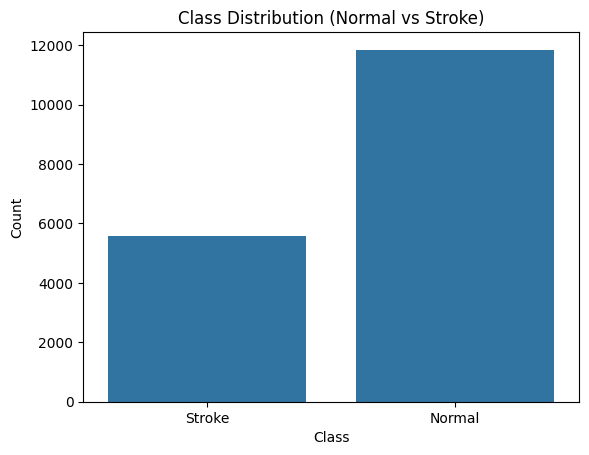

In [5]:
sns.countplot(x=df['class'])
plt.title('Class Distribution (Normal vs Stroke)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

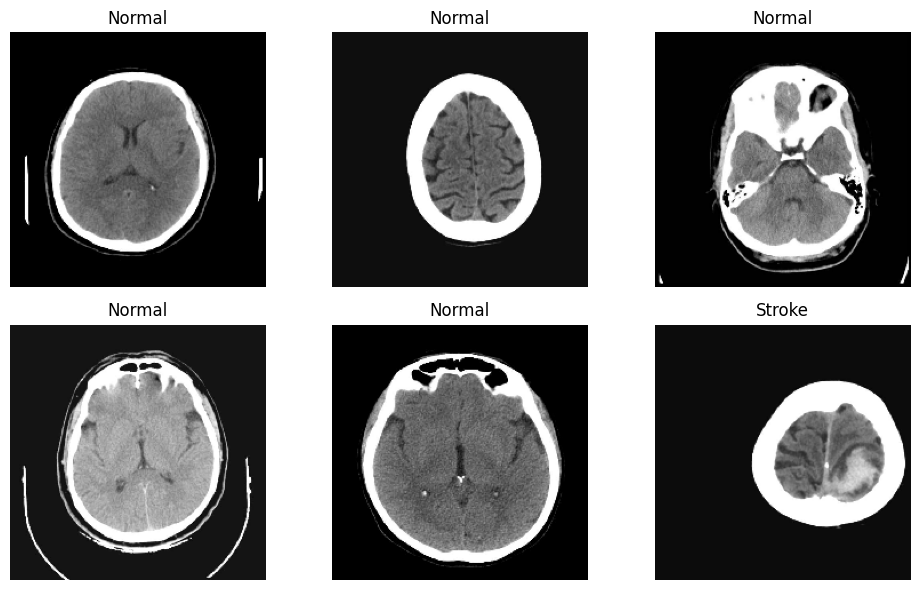

In [6]:
sample_paths = df.sample(6,random_state=2)

plt.figure(figsize=(10,6))
for i, row in enumerate(sample_paths.itertuples()):
  plt.subplot(2,3,i+1)
  img = load_img(row.filename, target_size=(224,224))
  plt.imshow(img)
  plt.title(row._2)
  plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["class"],
    random_state=42
)

Text(0.5, 1.0, 'Test Distribution')

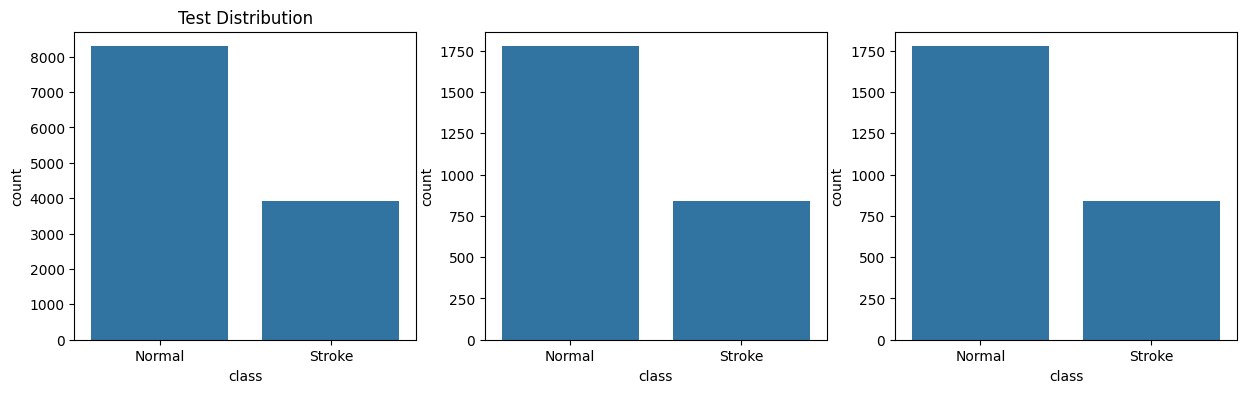

In [8]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

sns.countplot(x=train_df['class'], ax=axes[0])
axes[0].set_title('Train Distribution')

sns.countplot(x=val_df['class'], ax=axes[1])
axes[0].set_title('Validation Distribution')

sns.countplot(x=test_df['class'], ax=axes[2])
axes[0].set_title('Test Distribution')

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

val_gen = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 12201 validated image filenames belonging to 2 classes.
Found 2614 validated image filenames belonging to 2 classes.
Found 2615 validated image filenames belonging to 2 classes.


In [10]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)

model = Model(inputs=base_model.input, outputs=x)

I0000 00:00:1775638518.785911      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775638518.791655      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
def extract_features(generator, model):
    generator.reset()
    features = []
    labels = []

    steps = int(np.ceil(generator.samples / generator.batch_size))

    for _ in range(steps):
        x, y = next(generator)
        feat = model.predict(x, verbose=0)
        features.append(feat)
        labels.append(y)

    return np.vstack(features), np.hstack(labels)

In [12]:
X_train, y_train = extract_features(train_gen, model)
X_val, y_val = extract_features(val_gen, model)
X_test, y_test = extract_features(test_gen, model)


I0000 00:00:1775638524.886495     132 service.cc:152] XLA service 0x7821a00032d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775638524.886543     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775638524.886549     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775638526.144711     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775638532.377000     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [13]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))


In [14]:
ga = GAFeatureSelectionCV(
    estimator=SVC(kernel='rbf', probability=True, class_weight= class_weights),
    cv=3,
    scoring = "recall",
    population_size = 15,
    generations=15,
    n_jobs=-1,
    verbose=True
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('ga', ga),
    ('clf', SVC(kernel='rbf', probability=True, class_weight= class_weights))
])

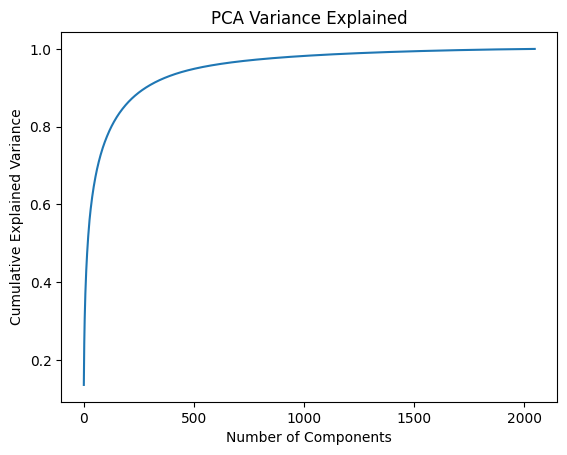

In [15]:
pca_temp=PCA().fit(X_train)

plt.plot(np.cumsum(pca_temp.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Explained')
plt.show()

In [16]:
pipeline.fit(X_train, y_train)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	15    	0.744043	0.00766119 	0.756011   	0.727625   
1  	30    	0.751494	0.00517447 	0.759334   	0.74246    
2  	30    	0.753982	0.00519304 	0.767264   	0.74527    
3  	30    	0.755807	0.00364345 	0.767264   	0.750642   
4  	30    	0.753625	0.0077082  	0.767264   	0.743225   
5  	30    	0.753846	0.00698537 	0.767264   	0.743478   
6  	30    	0.75666 	0.0071823  	0.767264   	0.743478   
7  	30    	0.756677	0.008025   	0.767264   	0.744247   
8  	30    	0.758093	0.00377876 	0.767264   	0.750899   
9  	30    	0.756063	0.00679376 	0.767264   	0.742201   
10 	30    	0.761127	0.00473358 	0.767264   	0.748338   
11 	30    	0.760053	0.00669451 	0.767264   	0.744248   
12 	30    	0.759831	0.00761654 	0.767776   	0.745272   
13 	30    	0.7562  	0.00763898 	0.767776   	0.745272   
14 	30    	0.758876	0.0081527  	0.767776   	0.743223   
15 	30    	0.761843	0.00739868 	0.768287   	0.745784   


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.9)),
                ('ga',
                 GAFeatureSelectionCV(estimator=SVC(class_weight={np.float32(0.0): np.float64(0.735797853093716),
                                                                  np.float32(1.0): np.float64(1.560230179028133)},
                                                    probability=True),
                                      generations=15, n_jobs=-1,
                                      population_size=15, scoring='recall')),
                ('clf',
                 SVC(class_weight={np.float32(0.0): np.float64(0.735797853093716),
                                   np.float32(1.0): np.float64(1.560230179028133)},
                     probability=True))])

In [17]:
y_val_pred = pipeline.predict(X_val)
y_val_prob = pipeline.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.89      0.90      1776
         1.0       0.78      0.79      0.78       838

    accuracy                           0.86      2614
   macro avg       0.84      0.84      0.84      2614
weighted avg       0.86      0.86      0.86      2614



In [18]:
y_test_pred = pipeline.predict(X_test)
y_test_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89      1777
         1.0       0.76      0.75      0.76       838

    accuracy                           0.85      2615
   macro avg       0.82      0.82      0.82      2615
weighted avg       0.85      0.85      0.85      2615



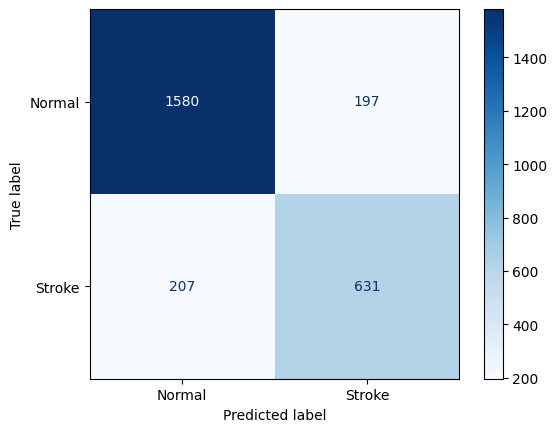

In [19]:
cm = confusion_matrix(y_test, y_test_pred)
labels = ["Normal", "Stroke"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")

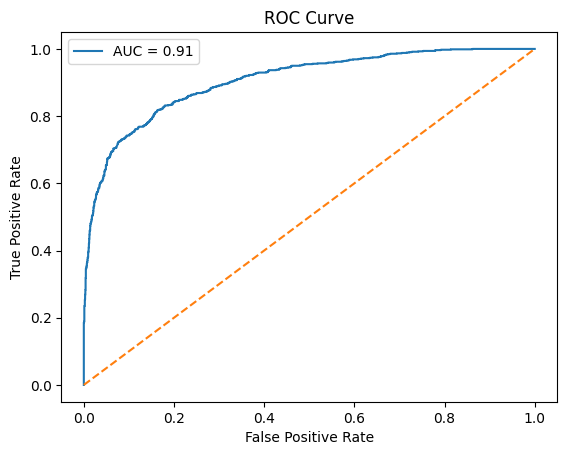

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [21]:
model.save("/kaggle/working/InceptionV3(svm).keras")
joblib.dump(pipeline, '/kaggle/working/pipeline(svm).pkl')

['/kaggle/working/pipeline(svm).pkl']

In [23]:
## for loading the model
model = keras.models.load_model('/kaggle/working/InceptionV3(svm).keras')
pipeline = joblib.load('/kaggle/working/pipeline(svm).pkl')